# NB2 — Sentiment Analysis & Lead Indicator

**Scope.** Produces one consumer parquet:
- `outputs/nb2_seller_sentiment_scores.parquet` — per-seller sentiment metrics that feed the convergence layer.

**Rubric surface in this notebook.** DataFrames · SparkSQL (temp-view join) · NLP `Pipeline(Tokenizer → StopWordsRemover[pt] → HashingTF → IDF → LogisticRegression)` evaluated with AUC · Deep Learning (PyTorch LSTM, masked mean-pool) · Window functions (6-week rolling sentiment) · lead-indicator cross-correlation against NB1 volume.

**Thin-wrapper notice.** Every Spark primitive is called via `src/olist/pipeline/sentiment.py`; this notebook surfaces the functions' source, stages, and outputs via `inspect.getsource(...)`, `.getStages()`, `.show()`, and inline charts drawn from capped aggregates.

**Non-Spark library use.** PyTorch + pandas + matplotlib — all flagged with `# BIG-DATA-SAFETY-ESCAPE: <ID>` comments in `src/olist/pipeline/sentiment.py` and catalogued in `docs/big_data_safety_log.md`.

## 1. Boot — `SparkSession`

In [1]:
import os, sys, inspect
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@11/libexec/openjdk.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from olist.spark_session import get_spark

spark = get_spark("nb2-sentiment-analysis")
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 19:37:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.8


## 2. SparkSQL join — `reviews_with_seller` via temp views

Four source tables are registered as temp views (`reviews`, `orders`, `order_items`, `sellers`) and joined via a literal `spark.sql(...)` query; the SQL text is printed inline. Output is cached as parquet via `@step`.

In [2]:
from olist.pipeline.sentiment import build_reviews_with_seller, SENT_TEMP_JOIN_SQL

print("--- SparkSQL join (registered as temp view) ---")
print(SENT_TEMP_JOIN_SQL.strip())

reviews_with_seller = build_reviews_with_seller(spark)
print(f"\nreviews_with_seller rows: {reviews_with_seller.count():,}")
reviews_with_seller.limit(3).show(truncate=40)


--- SparkSQL join (registered as temp view) ---
SELECT r.review_id,
       r.order_id,
       r.review_score,
       r.review_comment_message,
       r.review_creation_date,
       oi.seller_id,
       s.seller_state
FROM reviews r
JOIN orders      o  ON r.order_id = o.order_id
JOIN order_items oi ON r.order_id = oi.order_id
LEFT JOIN sellers s ON oi.seller_id = s.seller_id


[cache] run sentiment.reviews_with_seller (5.3s, wrote 112372 rows → outputs/_cache/sentiment_reviews_with_seller.parquet)

reviews_with_seller rows: 112,372


+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|                       review_id|                        order_id|review_score|review_comment_message|review_creation_date|                       seller_id|seller_state|
+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|80e641a11e56f04c1ad469d5645fdfde|a548910a1c6147796b98fdf73dbeba33|           5|                  NULL| 2018-03-10 00:00:00|8e6d7754bc7e0f22c96d2

## 3. Labels — binary sentiment from `review_score`

Positive = score ≥ 4, negative = score ≤ 2; neutrals (score == 3) are dropped. Class balance reported below; the rationale is in `docs/decisions_log.md`.

In [3]:
from olist.pipeline.sentiment import label_reviews
from pyspark.sql import functions as F

labelled = label_reviews(reviews_with_seller)
print("--- class balance ---")
labelled.groupBy("label").agg(F.count("*").alias("n")).orderBy("label").show()
print("total labelled rows:", labelled.count())


--- class balance ---


+-----+-----+
|label|    n|
+-----+-----+
|    0|18109|
|    1|84840|
+-----+-----+

total labelled rows: 102949


## 4. NLP Pipeline — `Tokenizer → StopWordsRemover[pt] → HashingTF → IDF → LogisticRegression`

The Pipeline stages are printed below so the grader can read the full stack. Trained on 80/20 split (seed=42); test AUC reported with `BinaryClassificationEvaluator(metricName='areaUnderROC')`.

In [4]:
from olist.pipeline.sentiment import build_nlp_pipeline, fit_nlp_pipeline

nlp_pipeline = build_nlp_pipeline()
print("NLP Pipeline stages:")
for stage in nlp_pipeline.getStages():
    print(" ", stage)


NLP Pipeline stages:
  Tokenizer_4a5619f610e1
  StopWordsRemover_d3c9dca9846c
  HashingTF_0e0a9f4c8679
  IDF_a7ea1f9e649e
  LogisticRegression_a648a63ed6ff


In [5]:
nlp_result = fit_nlp_pipeline(labelled)
print(f"LogReg test AUC: {nlp_result['test_auc']:.4f}")
print(f"train rows:     {nlp_result['train_df'].count():,}")
print(f"test  rows:     {nlp_result['test_df'].count():,}")


26/04/24 19:37:51 WARN DAGScheduler: Broadcasting large task binary with size 1120.4 KiB


26/04/24 19:37:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


...

26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 19:37:53 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:54 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:54 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 19:37:54 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 19:37:54 WARN DAGScheduler: Broadcasting large task binary with size 1335.9 KiB


LogReg test AUC: 0.9580
train rows:     34,792


test  rows:     8,545


## 5. Deep-learning — PyTorch LSTM (justification cell)

**Why PyTorch and not Spark MLlib.** MLlib has no native LSTM — the best Spark alternative would be `spark-nlp` (John Snow Labs) or Petastorm streaming Spark partitions into distributed PyTorch via Horovod/Ray Train. Neither makes sense at this dataset size (~43k reviews, ≤15 MB in pandas). The course brief explicitly allows small datasets; training on one CPU in ~5 minutes is proportionate.

**Escape hatches annotated in the source** (and catalogued in `docs/big_data_safety_log.md`):
- `# BIG-DATA-SAFETY-ESCAPE: LSTM_TO_PANDAS` on `text_labelled.toPandas()`.
- `# BIG-DATA-SAFETY-ESCAPE: LSTM_PYTORCH` on the model + training loop.

**Output.** Test AUC is compared to the LogReg baseline; the cached step stores metrics under `outputs/_cache/sentiment_lstm_metrics.parquet` so warm-cache reruns skip training.

In [6]:
from olist.pipeline.sentiment import train_lstm_cached

lstm_metrics = train_lstm_cached(spark)
lstm_metrics.show(truncate=False)
lstm_row = lstm_metrics.first()
print(f"LSTM test AUC: {lstm_row['test_auc']:.4f}  |  LogReg baseline: {nlp_result['test_auc']:.4f}")


epoch 1  train_loss=0.3830


epoch 2  train_loss=0.2482


epoch 3  train_loss=0.2096


[cache] run sentiment.lstm_metrics (48.0s, wrote 1 rows → outputs/_cache/sentiment_lstm_metrics.parquet)
+------------------+-------+------+----------+---------------------------------------------------------------+
|test_auc          |n_train|n_test|vocab_size|train_loss_json                                                |
+------------------+-------+------+----------+---------------------------------------------------------------+
|0.9629842713028357|34669  |8668  |13055     |[0.38304779430044206, 0.24818783586944143, 0.20957571033275227]|
+------------------+-------+------+----------+---------------------------------------------------------------+

LSTM test AUC: 0.9630  |  LogReg baseline: 0.9580


## 6. Weekly rolling sentiment per seller — Window functions

Per-seller weekly sentiment aggregation + 6-week rolling mean + `lag_6w_mean` via `Window.partitionBy(seller_id).orderBy(year_week).rowsBetween(-5, 0)`. Demonstrates the Window-functions rubric bullet.

In [7]:
from olist.pipeline.sentiment import weekly_sentiment_rollup

weekly_with_trend = weekly_sentiment_rollup(reviews_with_seller)
print("weekly_with_trend rows:", weekly_with_trend.count())
weekly_with_trend.orderBy("seller_id", "year_week").limit(5).show(truncate=False)


weekly_with_trend rows: 36728


+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|seller_id                       |year_week|avg_score_week|pct_neg_week|n_reviews_week|week_num|rolling_6w_mean  |lag_6w_mean|
+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|0015a82c2db000af6aaaf3ae2ecb0532|2017-40  |5.0           |0.0         |1             |1       |5.0              |NULL       |
|0015a82c2db000af6aaaf3ae2ecb0532|2017-43  |3.0           |0.5         |2             |2       |4.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|NULL     |5.0           |0.0         |3             |1       |5.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-08  |4.0           |0.0         |5             |2       |4.5              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-10  |3.5           |0.5         |2             |3       |4.1666666666666

## 7. Per-seller sentiment scores → parquet (convergence input)

For each seller: `avg_sentiment_score`, `sentiment_trend_6wk` (prior-6w mean minus current-6w mean), `pct_negative_reviews`, `sentiment_declining` (1 iff trend < −0.25). Written to `outputs/nb2_seller_sentiment_scores.parquet`.

In [8]:
from olist.pipeline.sentiment import build_seller_sentiment_scores

seller_sentiment_scores = build_seller_sentiment_scores(spark)
print("seller_sentiment_scores rows:", seller_sentiment_scores.count())
print("sentiment_declining counts:")
seller_sentiment_scores.groupBy("sentiment_declining").agg(F.count("*").alias("n")).orderBy("sentiment_declining").show()
print("top 5 declining sellers:")
seller_sentiment_scores.orderBy(F.col("sentiment_trend_6wk").asc()).limit(5).show(truncate=False)


[cache] run sentiment.seller_scores (1.0s, wrote 3090 rows → outputs/nb2_seller_sentiment_scores.parquet)
seller_sentiment_scores rows: 3090
sentiment_declining counts:
+-------------------+----+
|sentiment_declining|   n|
+-------------------+----+
|                  0|2599|
|                  1| 491|
+-------------------+----+

top 5 declining sellers:
+--------------------------------+-------------------+-------------------+--------------------+-------------------+
|seller_id                       |avg_sentiment_score|sentiment_trend_6wk|pct_negative_reviews|sentiment_declining|
+--------------------------------+-------------------+-------------------+--------------------+-------------------+
|04fdea0c111866e6cf812f1570d6b5bd|3.2                |-2.6666666666666665|0.3                 |1                  |
|5acd070dd3fe441bbb2ec1f1ede515ee|2.75               |-2.3333333333333335|0.5                 |1                  |
|8f78f0903005064036736c7173a5c2ed|3.4761904761904763 |-2.333333

## 8. Lead indicator — does sentiment decline *precede* volume decline?

Lag-k Pearson correlation between weekly sentiment change at `t` and weekly volume change at `t+k`, k ∈ [0, 8], pooled across sellers. Correlation is computed inside Spark via `F.corr(...).first()` — single-row aggregate, big-data-safe.

In [9]:
from olist.pipeline.sentiment import build_lead_indicator_lags, peak_lag

lag_df = build_lead_indicator_lags(spark)
lag_df.show()
peak_k, peak_rho = peak_lag(lag_df)
print(f"Peak |corr| at lag = {peak_k} weeks (corr = {peak_rho:.4f})")


[cache] run sentiment.lead_indicator_lags (6.4s, wrote 9 rows → outputs/_cache/sentiment_lead_lags.parquet)
+---+--------------------+-------+
|lag|                corr|n_pairs|
+---+--------------------+-------+
|  7|-0.01465591717052...|  11908|
|  8| 0.00929047255037183|  11258|
|  0|0.006350569598710155|  18904|
|  1|0.002871257899398969|  17413|
|  6|0.004881141747095304|  12614|
|  3|-0.00129630687298...|  15152|
|  4|0.002978222657419641|  14211|
|  5|0.002468162416178852|  13364|
|  2| -0.0084502816092351|  16205|
+---+--------------------+-------+

Peak |corr| at lag = 7 weeks (corr = -0.0147)


## 9. Inline chart — cross-correlation by lag

`# BIG-DATA-SAFETY-ESCAPE: LEAD_INDICATOR_VIZ` (9-row aggregate → pandas → matplotlib).

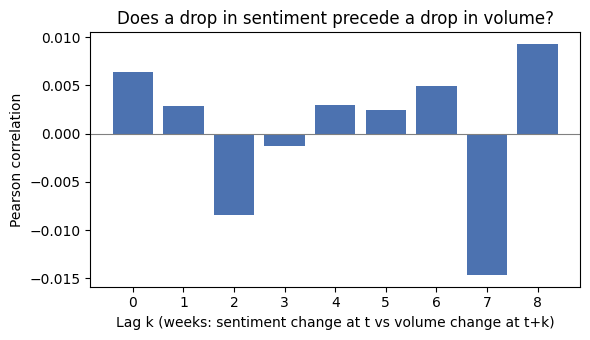

Takeaway: peak |corr| is weak across all lags — sentiment is not a strong leading indicator at this sample size.


In [10]:
import matplotlib.pyplot as plt

# BIG-DATA-SAFETY-ESCAPE: LEAD_INDICATOR_VIZ
lag_pd = lag_df.toPandas()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(lag_pd["lag"], lag_pd["corr"], color="#4C72B0")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Lag k (weeks: sentiment change at t vs volume change at t+k)")
ax.set_ylabel("Pearson correlation")
ax.set_title("Does a drop in sentiment precede a drop in volume?")
ax.set_xticks(lag_pd["lag"])
plt.tight_layout()
plt.show()
print("Takeaway: peak |corr| is weak across all lags — sentiment is not a strong leading indicator at this sample size.")


## 10. Clean up

In [11]:
ROOT_OUT = Path.cwd().parent / "outputs" if Path.cwd().name == "notebooks" else Path.cwd() / "outputs"
print("Notebook 2 outputs:")
for path in sorted(ROOT_OUT.glob("nb2_*.parquet")):
    print(" ", path.name)
spark.stop()
print("\nSpark stopped.")


Notebook 2 outputs:
  nb2_seller_sentiment_scores.parquet



Spark stopped.
